# Autoencoder Reconstruction Comparison

Evaluate selected `.pt` models on one fixed test image list and compare reconstruction metrics.

In [1]:
import os
import math
import yaml
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import importlib

import autoencoder
import data
importlib.reload(autoencoder)
importlib.reload(data)

Autoencoder = autoencoder.Autoencoder
make_data = data.make_data

In [2]:
TEST_ID_PATH = '../results/exp_018/exp_018_pretrain_test_ids.txt'
DATA_DIR = '../data'
PATCH_SIZE = 9
BATCH_SIZE = 4096
OUTPUT_CSV = '../results/autoencoder_benchmark.csv'

# Create list of models to evaluate
MODELS = []

for exp in range(18, 46):
    exp_id = f'{exp:03d}'

    cfg_pre = f'./configs/exp_{exp_id}_pretrain.yaml'
    w_pre = f'../results/exp_{exp_id}/exp_{exp_id}_pretrain.pt'
    if os.path.exists(cfg_pre) and os.path.exists(w_pre):
        MODELS.append({
            'name': f'exp_{exp_id}_pretrain',
            'group': 'pretrain',
            'config_path': cfg_pre,
            'weights_path': w_pre,
        })

    cfg_fine = f'./configs/exp_{exp_id}_finetune.yaml'
    w_fine = f'../results/exp_{exp_id}/exp_{exp_id}_finetune.pt'
    if os.path.exists(cfg_fine) and os.path.exists(w_fine):
        MODELS.append({
            'name': f'exp_{exp_id}_finetune',
            'group': 'finetune',
            'config_path': cfg_fine,
            'weights_path': w_fine,
        })


In [3]:
# create a set of test image ids
with open(TEST_ID_PATH, 'r') as f:
    test_ids = [line.strip() for line in f if line.strip()]

# create a mapping from image_id to npz filepath
all_npz = {}
for fn in os.listdir(DATA_DIR):
    if fn.endswith('.npz'):
        image_id = fn[:-4]
        all_npz[image_id] = os.path.join(DATA_DIR, fn)

# make a list of filepaths for the test set
test_filepaths = []
for image_id in test_ids:
    if image_id not in all_npz:
        raise ValueError(f'missing npz for {image_id}')
    test_filepaths.append(all_npz[image_id])

# prepare all test patches
images_long, patches = make_data(patch_size=PATCH_SIZE, filepaths=test_filepaths)
all_patch_arrays = []
for p in patches:
    all_patch_arrays.append(np.asarray(p, dtype=np.float32))
all_patches = np.concatenate(all_patch_arrays, axis=0)
x_all = torch.tensor(all_patches, dtype=torch.float32)
print('n_test_images =', len(test_ids))
print('n_test_patches =', x_all.shape[0])

# evaluate each model
rows = []

for m in MODELS:
    print('evaluating:', m['name'])

    # load model
    with open(m['config_path'], 'r') as f:
        cfg = yaml.safe_load(f)
    model = Autoencoder(patch_size=cfg['data']['patch_size'], **cfg['autoencoder'])
    weights = torch.load(m['weights_path'], map_location='cpu')

    # compatible with previous versions of model architecture
    try:
        model.load_state_dict(weights)
    except RuntimeError:
        ae_cfg = dict(cfg['autoencoder'])
        ae_cfg['dropout_rate'] = 0.0
        model = Autoencoder(patch_size=cfg['data']['patch_size'], **ae_cfg)
        model.load_state_dict(weights)

    model.eval()

    se_sum = 0.0
    ae_sum = 0.0
    n_elem = 0

    # compute reconstruction errors
    for i in tqdm(range(0, x_all.shape[0], BATCH_SIZE)):
        xb = x_all[i:i + BATCH_SIZE]
        with torch.no_grad():
            pred = model(xb)
        diff = pred - xb
        se_sum += torch.sum(diff * diff).item()
        ae_sum += torch.sum(torch.abs(diff)).item()
        n_elem += diff.numel()
    mse = se_sum / n_elem
    rmse = math.sqrt(mse)
    mae = ae_sum / n_elem

    data_range = float(x_all.max().item() - x_all.min().item())
    if data_range <= 0:
        psnr = float('nan')
    else:
        psnr = 20.0 * math.log10(data_range) - 10.0 * math.log10(mse)

    rows.append({
        'name': m['name'],
        'group': m['group'],
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'psnr': psnr,
    })

df = pd.DataFrame(rows).sort_values('mse').reset_index(drop=True)
df.to_csv(OUTPUT_CSV, index=False)
print('saved:', OUTPUT_CSV)
df

done reshaping images
working on image 0
working on image 10
n_test_images = 17
n_test_patches = 1962097
evaluating: exp_018_pretrain


100%|██████████| 480/480 [00:01<00:00, 399.17it/s]


evaluating: exp_018_finetune


100%|██████████| 480/480 [00:01<00:00, 426.65it/s]


evaluating: exp_019_pretrain


...

100%|██████████| 480/480 [03:44<00:00,  2.14it/s]


evaluating: exp_045_finetune


100%|██████████| 480/480 [03:45<00:00,  2.13it/s]

saved: ../results/autoencoder_benchmark.csv


,name,group,mse,rmse,mae,psnr
0,exp_029_finetune,finetune,0.118357,0.344031,0.204616,33.672664
1,exp_028_finetune,finetune,0.118591,0.344371,0.205135,33.664100
2,exp_028_pretrain,pretrain,0.118697,0.344524,0.204885,33.660221
3,exp_039_finetune,finetune,0.118878,0.344788,0.205426,33.653591
4,exp_029_pretrain,pretrain,0.119609,0.345845,0.205780,33.626980
5,exp_039_pretrain,pretrain,0.120278,0.346812,0.206769,33.602745
6,exp_025_finetune,finetune,0.120773,0.347524,0.206608,33.584919
7,exp_027_finetune,finetune,0.120855,0.347642,0.203956,33.581967
8,exp_024_finetune,finetune,0.120920,0.347735,0.206687,33.579645
9,exp_031_finetune,finetune,0.121579,0.348681,0.207272,33.556044


## Data Splitting

Count how many images and patches in each set.


In [4]:
import io
import yaml
import numpy as np
from contextlib import redirect_stdout
from data import make_data_on_the_fly

exp_id = '029'

def summarize(stage):
    cfg_path = f'./configs/exp_{exp_id}_{stage}.yaml'
    cfg = yaml.safe_load(open(cfg_path, 'r'))

    np.random.seed(cfg.get('seed', 0))
    data_mode = cfg.get('data', {}).get('mode', 'all')
    with redirect_stdout(io.StringIO()):
        _, _, coords, _ = make_data_on_the_fly(
            patch_size=cfg['data']['patch_size'],
            mode=data_mode,
        )

    image_ids = np.unique(coords[:, 0])
    split_cfg = cfg.get('split', {})
    train_ratio = split_cfg.get('train_ratio', 0.8)
    test_ratio = split_cfg.get('test_ratio', 0.0)
    val_ratio = split_cfg['val_ratio'] if 'val_ratio' in split_cfg else (1.0 - train_ratio - test_ratio)

    shuffled = np.random.permutation(image_ids)
    n_train = int(len(shuffled) * train_ratio)
    n_val = int(len(shuffled) * val_ratio)

    train_ids = shuffled[:n_train]
    val_ids = shuffled[n_train:n_train + n_val]
    test_ids = shuffled[n_train + n_val:]

    train_idx = np.where(np.isin(coords[:, 0], train_ids))[0]
    val_idx = np.where(np.isin(coords[:, 0], val_ids))[0]
    test_idx = np.where(np.isin(coords[:, 0], test_ids))[0]

    n_img = len(image_ids)
    n_patch = len(coords)

    print(stage)
    print(f"images: train {len(train_ids)} ({len(train_ids)/n_img:.2%}), val {len(val_ids)} ({len(val_ids)/n_img:.2%}), test {len(test_ids)} ({len(test_ids)/n_img:.2%})")
    print(f"patches: train {len(train_idx)} ({len(train_idx)/n_patch:.2%}), val {len(val_idx)} ({len(val_idx)/n_patch:.2%}), test {len(test_idx)} ({len(test_idx)/n_patch:.2%})")

summarize('pretrain')
print()
summarize('finetune')


pretrain
images: train 128 (79.50%), val 16 (9.94%), test 17 (10.56%)
patches: train 14779819 (79.51%), val 1847708 (9.94%), test 1962097 (10.55%)

finetune
images: train 6 (100.00%), val 0 (0.00%), test 0 (0.00%)
patches: train 690010 (100.00%), val 0 (0.00%), test 0 (0.00%)


## Reconstruction Plot

Load `exp_029_finetune` and visualize image `O013490` (original vs reconstruction) across all 8 channels.


done reshaping images


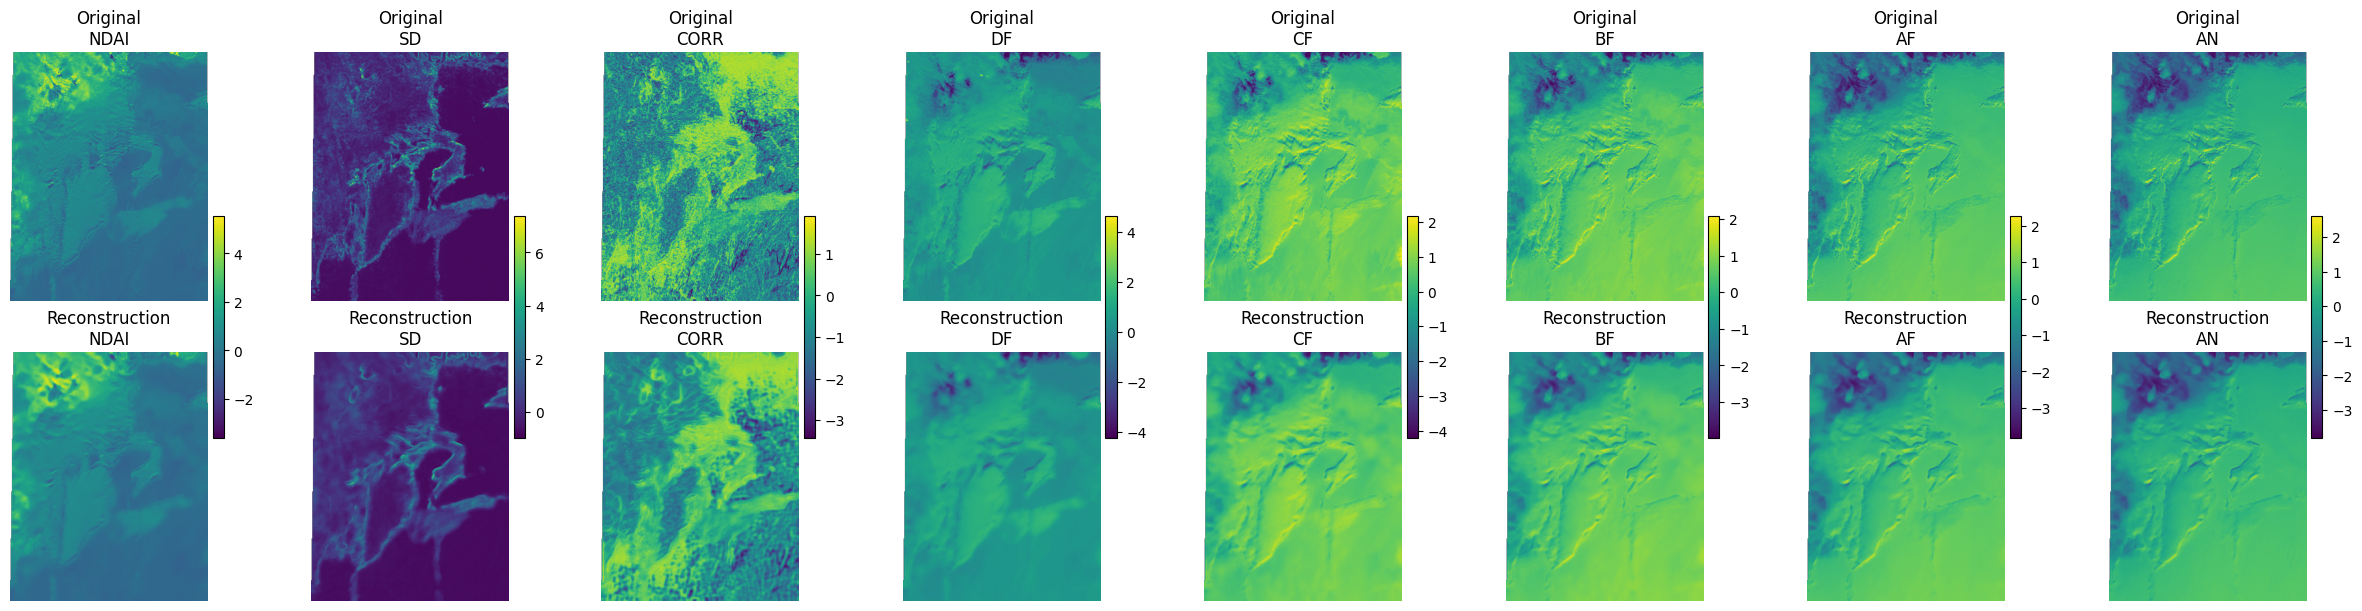

MSE on O013490: 0.080823


In [5]:
import os
from data import make_data_on_the_fly
from autoencoder import Autoencoder

# load images
EXP_ID = '029'
STAGE = 'finetune'
TARGET_IMAGE_ID = 'O013490'
BATCH_SIZE = 4096
cfg_path = f'./configs/exp_{EXP_ID}_{STAGE}.yaml'
weights_path = f'../results/exp_{EXP_ID}/exp_{EXP_ID}_{STAGE}.pt'

with open(cfg_path, 'r') as f:
    cfg = yaml.safe_load(f)

images_long, images_padded, coords, image_codes = make_data_on_the_fly(
    patch_size=cfg['data']['patch_size'],
    mode=cfg.get('data', {}).get('mode', 'all'),
)

# find coordinates for the target image
target_image_idx = image_codes.index(TARGET_IMAGE_ID)
mask = coords[:, 0] == target_image_idx
coords_target = coords[mask]

# load model and weights
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = Autoencoder(
    patch_size=cfg['data']['patch_size'],
    images_padded=images_padded,
    **cfg['autoencoder'],
).to(device)

weights = torch.load(weights_path, map_location='cpu')

# keep compatibility with older checkpoints that may not include dropout_rate.
try:
    model.load_state_dict(weights)
except RuntimeError:
    ae_cfg = dict(cfg['autoencoder'])
    ae_cfg['dropout_rate'] = 0.0
    model = Autoencoder(
        patch_size=cfg['data']['patch_size'],
        images_padded=images_padded,
        **ae_cfg,
    ).to(device)
    model.load_state_dict(weights)

# compute reconstructions for all patches in the target image
model.eval()

image_idx_t = torch.as_tensor(coords_target[:, 0], dtype=torch.long, device=device)
y_rel_t = torch.as_tensor(coords_target[:, 1], dtype=torch.long, device=device)
x_rel_t = torch.as_tensor(coords_target[:, 2], dtype=torch.long, device=device)

center = cfg['data']['patch_size'] // 2
orig_centers = []
recon_centers = []

with torch.no_grad():
    for start in range(0, len(coords_target), BATCH_SIZE):
        end = start + BATCH_SIZE
        batch = (image_idx_t[start:end], y_rel_t[start:end], x_rel_t[start:end])
        patches = model._prepare_batch(batch)
        recon = model(patches)
        orig_centers.append(patches[:, :, center, center].cpu().numpy())
        recon_centers.append(recon[:, :, center, center].cpu().numpy())

orig_centers = np.concatenate(orig_centers, axis=0)
recon_centers = np.concatenate(recon_centers, axis=0)

# create maps for original and reconstructed center pixels
y_min = int(coords_target[:, 1].min())
y_max = int(coords_target[:, 1].max())
x_min = int(coords_target[:, 2].min())
x_max = int(coords_target[:, 2].max())
height = y_max - y_min + 1
width = x_max - x_min + 1
n_channels = orig_centers.shape[1]

orig_map = np.full((n_channels, height, width), np.nan, dtype=np.float32)
recon_map = np.full((n_channels, height, width), np.nan, dtype=np.float32)

y_idx = coords_target[:, 1].astype(int) - y_min
x_idx = coords_target[:, 2].astype(int) - x_min

for i, (yy, xx) in enumerate(zip(y_idx, x_idx)):
    orig_map[:, yy, xx] = orig_centers[i]
    recon_map[:, yy, xx] = recon_centers[i]

channel_names = ['NDAI', 'SD', 'CORR', 'DF', 'CF', 'BF', 'AF', 'AN']
if len(channel_names) != n_channels:
    channel_names = [f'ch_{i}' for i in range(n_channels)]

# visualize original and reconstructed maps side by side
fig, axes = plt.subplots(2, n_channels, figsize=(3 * n_channels, 6), constrained_layout=True)

for c in range(n_channels):
    vmin = np.nanmin([np.nanmin(orig_map[c]), np.nanmin(recon_map[c])])
    vmax = np.nanmax([np.nanmax(orig_map[c]), np.nanmax(recon_map[c])])
    im = axes[0, c].imshow(orig_map[c], cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0, c].set_title(f'Original\n{channel_names[c]}')
    axes[0, c].axis('off')
    axes[1, c].imshow(recon_map[c], cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1, c].set_title(f'Reconstruction\n{channel_names[c]}')
    axes[1, c].axis('off')
    fig.colorbar(im, ax=[axes[0, c], axes[1, c]], fraction=0.045, pad=0.02)

# save the figure
fig_dir = '../figs'
os.makedirs(fig_dir, exist_ok=True)
recon_fig_path = f'{fig_dir}/{TARGET_IMAGE_ID}_reconstruction.png'
fig.savefig(recon_fig_path, dpi=300, bbox_inches='tight')

plt.show()

# compute MSE for center pixels
mse_center = np.nanmean((orig_map - recon_map) ** 2)
print(f'MSE on {TARGET_IMAGE_ID}: {mse_center:.6f}')



## Latent Visualization

Visualize one latent variable (`ae_3`) from `exp_029_finetune` on `O013490` alongside the original cloud label map.


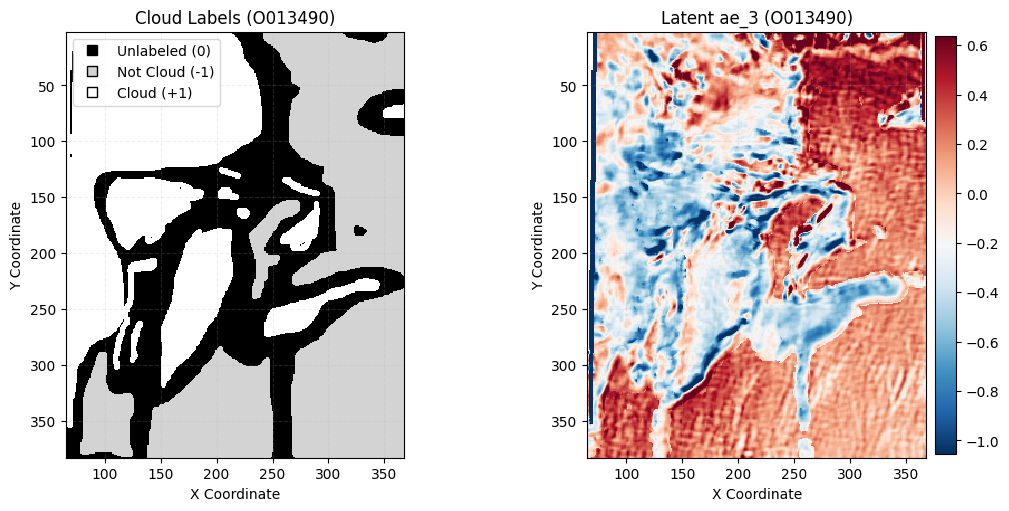

In [6]:
import os
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D

arr = np.load(f'../data/{TARGET_IMAGE_ID}.npz')
raw = arr[arr.files[0]]
y = raw[:, 0].astype(int)
x = raw[:, 1].astype(int)
label = raw[:, -1].astype(int)

BATCH_SIZE_LATENT = 8192
emb_list = []
with torch.no_grad():
    for s in range(0, len(coords_target), BATCH_SIZE_LATENT):
        e = s + BATCH_SIZE_LATENT
        batch = (image_idx_t[s:e], y_rel_t[s:e], x_rel_t[s:e])
        patches = model._prepare_batch(batch)
        emb_list.append(model.embed(patches).cpu().numpy())
emb = np.concatenate(emb_list, axis=0)

ae_dim = 4
ae_val = emb[:, ae_dim - 1]

# build 2D maps on the original coordinate grid
ymin, ymax = y.min(), y.max()
xmin, xmax = x.min(), x.max()
height = ymax - ymin + 1
width = xmax - xmin + 1

cloud_map = np.full((height, width), np.nan, dtype=np.float32)
ae_map = np.full((height, width), np.nan, dtype=np.float32)

yy = y - ymin
xx = x - xmin
cloud_map[yy, xx] = label
ae_map[yy, xx] = ae_val

# stronger contrast for ae_3 using robust clipping
vmin, vmax = np.nanpercentile(ae_map, [2, 98])
if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
    vmin, vmax = np.nanmin(ae_map), np.nanmax(ae_map)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

cmap_cloud = ListedColormap(['lightgray', 'black', 'white'])
norm_cloud = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap_cloud.N)

ax[0].imshow(
    cloud_map,
    cmap=cmap_cloud,
    norm=norm_cloud,
    interpolation='nearest',
    extent=(xmin, xmax, ymax, ymin),
)
ax[0].set_title(f'Cloud Labels ({TARGET_IMAGE_ID})')
ax[0].set_xlabel('X Coordinate')
ax[0].set_ylabel('Y Coordinate')
ax[0].grid(True, linestyle='--', alpha=0.2)
legend_elements = [
    Line2D([0], [0], marker='s', linestyle='None', markerfacecolor='black', markeredgecolor='black',
           markersize=7, label='Unlabeled (0)'),
    Line2D([0], [0], marker='s', linestyle='None', markerfacecolor='lightgray', markeredgecolor='black',
           markersize=7, label='Not Cloud (-1)'),
    Line2D([0], [0], marker='s', linestyle='None', markerfacecolor='white', markeredgecolor='black',
           markersize=7, label='Cloud (+1)'),
]
ax[0].legend(handles=legend_elements, loc='upper left', frameon=True)

im = ax[1].imshow(
    ae_map,
    cmap='RdBu_r',
    vmin=vmin,
    vmax=vmax,
    interpolation='nearest',
    extent=(xmin, xmax, ymax, ymin),
)
ax[1].set_title(f'Latent ae_{ae_dim-1} ({TARGET_IMAGE_ID})')
ax[1].set_xlabel('X Coordinate')
ax[1].set_ylabel('Y Coordinate')
ax[1].grid(True, linestyle='--', alpha=0.2)
fig.colorbar(im, ax=ax[1], fraction=0.046, pad=0.02)

# save the figure
fig_dir = '../figs'
os.makedirs(fig_dir, exist_ok=True)
latent_fig_path = f'{fig_dir}/{TARGET_IMAGE_ID}_latent_ae_{ae_dim-1}.png'
fig.savefig(latent_fig_path, dpi=300, bbox_inches='tight')

plt.show()


